In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Read genebass associations

In [9]:
# Read the full Genebass results
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
        phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
        region = pl.col('gene_id'),
        gene_name = pl.col('gene_symbol'),
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('trait_type') == 'continuous') &
        # (pl.col('annotation').str.contains('pLoF'))
        (pl.col('annotation') == 'pLoF')
    )
    .select(['region', 'gene_name', 'phenotype', 'trait_type'])
    .unique()
)

gene_trait_df = gb_pl[['region', 'gene_name', 'phenotype', 'trait_type']].unique()

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)
gene_trait_df = gb_pl.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner')

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

gene_trait_df = gene_trait_df.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
    sign_agreement = (pl.col('loftee_corr')*pl.col('beta') > 0) & (pl.col('loftee_corr').is_not_nan()),
    corr_dir = (pl.col('loftee_corr')/pl.col('loftee_corr').abs())
)

# TODO: We don't cover all genebass significant genes, so we need to filter out nans (LOFTEE correlations missing)
# gene_trait_df = gene_trait_df.filter(pl.col('sign_agreement')==1)
gene_trait_df

region,gene_name,phenotype,trait_type,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement,corr_dir
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,bool,f32
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""","""continuous""",-0.195409,9.1637e-8,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,true,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""","""continuous""",-0.397279,0.006626,530,530,13,-0.219682,"[1, 1, … 1]","""chr11:14493694:G:A""",1,0.024528,-5.174315,3.2549e-7,true,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""","""continuous""",-0.058463,0.000305,1098,1098,106,-0.036752,"[627, 129, … 1]","""chr14:58428357:T:TC""",627,0.096539,-1.217545,0.223659,true,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""","""continuous""",-0.436618,6.0395e-11,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,true,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""","""continuous""",-0.412619,2.8609e-8,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,true,-1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""","""continuous""",0.952411,1.8038e-41,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,true,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""continuous""",0.656849,2.1682e-10,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,true,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""",0.176348,2.1188e-7,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,true,1.0


In [10]:
a = gene_trait_df[['phenotype', 'gene_name', 'region', 'top_plof_var', 'top_plof_var_count']].group_by('gene_name').agg(
    pl.col('top_plof_var').n_unique(),
    pl.col('top_plof_var_count').n_unique()
).sort('top_plof_var', descending=True)

a.filter(pl.col('top_plof_var') > 1)

gene_name,top_plof_var,top_plof_var_count
str,u64,u64
"""RORC""",3,1
"""RRM1""",3,1
"""SUPT5H""",2,1
"""COPB1""",2,1
"""IRS1""",2,5
…,…,…
"""NPR2""",2,2
"""RIF1""",2,2
"""SLC4A1""",2,2


## Plot single gene-trait assoc

In [ ]:
gene_name = 'APOB'
phenotype = 'ldl_direct_int'

gtdf = gene_trait_df.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
)
gene_id = gtdf['region'].unique().item()

ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)
var_list = set(pl.read_parquet('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet', columns=['id',  'af_ukb']).filter(pl.col('af_ukb') < 1e-3)['id'].to_list()) #- set(['chr2:21043920:AGCAGCGCG:A'])
ag.subset_variants(var_list)
gdata = ag.get_many_regions([gene_id])[gene_id]

# --- Get top plof variant and compute burdens ---
tpv = gtdf['top_plof_var'].item()
indices = np.where(gdata['variant_ids'] == tpv)[0]

# --- Drop top plof variant and compute burdens ---
# gdata['genotypes'] = np.delete(gdata['genotypes'], indices, axis=0)
# gdata['annotations'] = gdata['annotations'].filter(pl.col('id')!=tpv)

plof_burdens = pl.DataFrame({
    'individual': ag.samples,
    'burden': gdata['genotypes'].T @ gdata['annotations']['loftee_hc'].to_numpy()
})#.filter(pl.col('burden') < 2)

# --- 2. Read and merge data ---
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).select("IID", phenotype).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).select("IID", f"{phenotype}_prs").rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

# Join everything and collect into a pandas DataFrame for the regression
merged_pd = (
    pheno_lazy
    .join(prs_lazy, on="individual", how="inner")
    .join(cov_lazy, on="individual", how="inner")
    .drop_nulls()
    .drop_nans()
    .collect()
    .to_pandas()
)

# --- 3. Compute residuals for the single phenotype ---
# Define the dependent (y) and independent (X) variables
y = merged_pd[phenotype]
X = merged_pd[[f"{phenotype}_prs"] + cov_list]
X = sm.add_constant(X) # Add an intercept

# Fit the linear model and get the residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# --- 4. Create the final long-format DataFrame ---
p_df = pl.DataFrame({
    "individual": merged_pd["individual"].astype(str),
    "phenotype": phenotype,
    "pheno_value": residuals
})

# 4. Join with gene burdens
plot_gp_df = plof_burdens.join(p_df, on='individual', how='inner')
print('Number of plofs:', plot_gp_df['burden'].sum())

plot_gp_df

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


Number of plofs: 847


individual,burden,phenotype,pheno_value
str,i8,str,f64
"""3834985""",0,"""ldl_direct_int""",-0.016527
"""1649233""",0,"""ldl_direct_int""",0.400111
"""5689749""",0,"""ldl_direct_int""",-0.761904
"""1160905""",0,"""ldl_direct_int""",2.267405
"""5102203""",0,"""ldl_direct_int""",0.03693
…,…,…,…
"""2864227""",0,"""ldl_direct_int""",-0.894074
"""5733954""",0,"""ldl_direct_int""",0.548599
"""3923515""",0,"""ldl_direct_int""",-0.737069


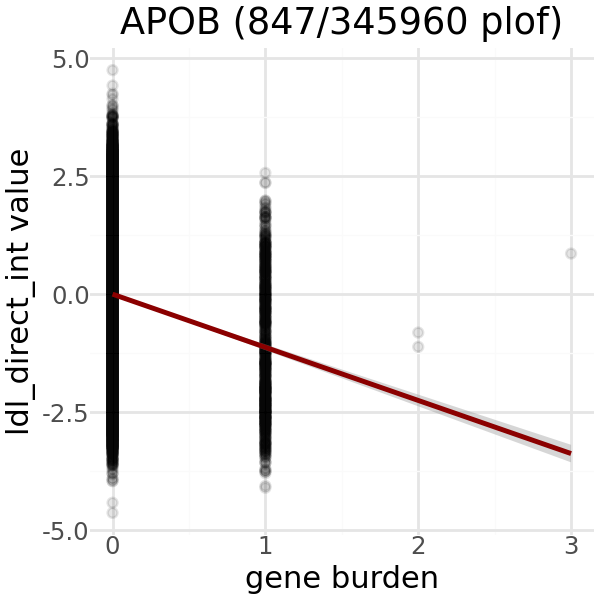

In [21]:
(
    ggplot(plot_gp_df, aes(x='burden', y='pheno_value')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='gene burden',
        y=f"{phenotype} value",
        title=f"{gene_name} ({plot_gp_df['burden'].sum()}/{plot_gp_df.shape[0]} plof)"
    ) +
    theme(figure_size=(3, 3))
)

## Get p-values across all associations

In [2]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)
var_list = set(pl.read_parquet('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet', columns=['id', 'af_ukb']).filter(pl.col('af_ukb') < 1e-3)['id'].to_list())
ag.subset_variants(var_list)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


In [3]:
plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

plof = plof[['region', 'gene_id', 'gene_name', 'phenotype', 'beta', 'rvat_pval']].join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='inner')
plof

region,gene_id,gene_name,phenotype,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64
"""ENSG00000175756""","""ENSG00000175756""","""AURKAIP1""","""arm_fatfree_mass_right_int""",0.02767,0.68834,212,212,17,-0.085663,"[183, 31, … 1]","""chr1:1374297:CCT:C""",183,0.080189,-1.245953,0.21417
"""ENSG00000157933""","""ENSG00000157933""","""SKI""","""arm_fatfree_mass_right_int""",0.118574,0.192994,800,800,13,0.062958,"[12, 3, … 1]","""chr1:2303402:T:G""",12,0.01625,1.782042,0.075123
"""ENSG00000116151""","""ENSG00000116151""","""MORN1""","""arm_fatfree_mass_right_int""",0.0923462,0.019837,504,504,31,0.05529,"[312, 26, … 1]","""chr1:2336818:AG:A""",312,0.061508,1.240696,0.215297
"""ENSG00000157881""","""ENSG00000157881""","""PANK4""","""arm_fatfree_mass_right_int""",0.288181,0.000778,779,779,34,0.067398,"[13, 7, … 1]","""chr1:2514399:CG:C""",13,0.043646,1.88298,0.060076
"""ENSG00000130762""","""ENSG00000130762""","""ARHGEF16""","""arm_fatfree_mass_right_int""",-0.016033,0.613167,661,661,52,-0.046185,"[63, 48, … 1]","""chr1:3478027:G:C""",63,0.078669,-1.186892,0.235698
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000159069""","""ENSG00000159069""","""FBXW5""","""heel_bone_mineral_density_bmd_…",0.003705,0.964175,610,610,54,-0.06342,"[43, 19, … 1]","""chr9:136941528:GAGGCCCACCTGTTG…",43,0.088525,-1.566947,0.117647
"""ENSG00000107331""","""ENSG00000107331""","""ABCA2""","""heel_bone_mineral_density_bmd_…",-0.066828,0.735872,1170,1170,24,-0.02843,"[358, 6, … 1]","""chr9:137008510:CG:C""",358,0.020513,-0.972031,0.331236
"""ENSG00000198569""","""ENSG00000198569""","""SLC34A3""","""heel_bone_mineral_density_bmd_…",-0.004881,0.931048,428,428,29,-0.061895,"[119, 12, … 1]","""chr9:137232928:G:A""",119,0.067757,-1.279943,0.201262


In [4]:
from statsmodels.stats.multitest import multipletests

# Function to apply BH correction within each group
def apply_bh_correction(group_df: pl.DataFrame) -> pl.DataFrame:
    p_values = group_df.get_column('rvat_pval').to_numpy()
    _, p_adj, _, _ = multipletests(p_values, method='fdr_bh')
    return group_df.with_columns(p_adj_bh=pl.Series(p_adj))

# gene_trait_df = plof.filter(pl.col('gene_id').is_in(ag.region_ids)).group_by('phenotype').map_groups(apply_bh_correction).filter(pl.col('p_adj_bh') < 0.05)

# Apply bonferroni correction
gene_trait_df = plof.filter(pl.col('gene_id').is_in(ag.region_ids)).with_columns(
    p_adj_bonf = pl.min_horizontal(pl.col('rvat_pval')*17_500, 1)
).filter(pl.col('p_adj_bonf') < 0.05)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_id,gene_name,phenotype,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,p_adj_bonf
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,f64
"""ENSG00000116183""","""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.195409,9.1637e-8,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,0.001604
"""ENSG00000257727""","""ENSG00000257727""","""CNPY2""","""arm_fatfree_mass_right_int""",-0.238033,7.7314e-7,141,141,19,-0.135488,"[56, 18, … 1]","""chr12:56315128:ACCTCCACAGT:A""",56,0.134752,-1.612251,0.109176,0.01353
"""ENSG00000157766""","""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.436618,6.0395e-11,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,0.000001
"""ENSG00000140443""","""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.412619,2.8609e-8,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,0.000501
"""ENSG00000131482""","""ENSG00000131482""","""G6PC1""","""arm_fatfree_mass_right_int""",-0.110167,8.0048e-7,268,268,24,0.030656,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.089552,0.500214,0.617338,0.014008
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.952411,1.8038e-41,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,3.1567e-37
"""ENSG00000029534""","""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.656849,2.1682e-10,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,0.000004
"""ENSG00000197969""","""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.176348,2.1188e-7,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,0.003708


In [5]:
# gene_id = 'ENSG00000130164'
rvat_df_list = []
for gene_id in tqdm(gene_trait_df['region'].unique().to_list()):
    gdata = ag.get_many_regions([gene_id])[gene_id]
    gene_name = gene_trait_df.filter(pl.col('region') == gene_id)['gene_name'].unique().item()

    pheno_list = gene_trait_df.filter(pl.col('region') == gene_id)['phenotype'].to_list()
    for phenotype in tqdm(pheno_list):
        gtdf = gene_trait_df.filter(
            (pl.col('phenotype') == phenotype) &
            (pl.col('region') == gene_id)
        )
        if gtdf['n_plof_variants'].item() > 1:
            tpv = gtdf['top_plof_var'].item()
            indices = np.where(gdata['variant_ids'] == tpv)[0]
            plof_burdens = pl.DataFrame({
                'individual': ag.samples,
                'burden': np.delete(gdata['genotypes'], indices, axis=0).T @ gdata['annotations'].filter(pl.col('id')!=tpv)['loftee_hc'].to_numpy()
            })#.filter(pl.col('burden') < 2)

            # Join everything and collect into a pandas DataFrame for the regression
            merged_pd = (
                pheno_lazy.select("individual", phenotype)
                .join(plof_burdens.lazy(), on="individual", how="inner")
                .join(prs_lazy.select("individual", f"{phenotype}_prs"), on="individual", how="inner")
                .join(cov_lazy, on="individual", how="inner")
                .drop_nulls()
                .drop_nans()
                .collect(engine='streaming')
            )

            # --- 3. Compute residuals for the single phenotype ---
            y = merged_pd[phenotype].to_numpy()
            X = merged_pd[["burden", f"{phenotype}_prs"] + cov_list].to_numpy()
            X = sm.add_constant(X) # Add an intercept

            # Fit the linear model and get the residuals
            model = sm.OLS(y, X).fit()
            pval = model.pvalues[1]
            beta = model.params[1]
            n_plofs = int(plof_burdens['burden'].sum())

        else:
            pval = np.nan
            beta = np.nan
            n_plofs = 0

        rvat_df_list.append(pl.DataFrame({
            "phenotype": phenotype,
            "gene_name": gene_name,
            "region": gene_id,
            "p_value": pval,
            "beta": beta,
            "n_variants": gtdf['n_variants'].item(),
            "n_plofs": n_plofs,
            "dropped_plof_count": gtdf['top_plof_var_count'].item(),
            "dropped_plof": gtdf['top_plof_var'].item(),
        }))

rvat_wo_top_plof = pl.concat(rvat_df_list)
rvat_wo_top_plof

100%|██████████| 310/310 [46:54<00:00,  9.08s/it]


phenotype,gene_name,region,p_value,beta,n_variants,n_plofs,dropped_plof_count,dropped_plof
str,str,str,f64,f64,i64,i64,i64,str
"""whole_body_fatfree_mass_int""","""CDC25B""","""ENSG00000101224""",0.000083,-0.282046,993,114,15,"""chr20:3800970:G:A"""
"""red_blood_cell_erythrocyte_cou…","""CAD""","""ENSG00000084774""",4.3783e-11,-0.422198,1623,205,23,"""chr2:27222208:G:T"""
"""red_blood_cell_erythrocyte_dis…","""CAD""","""ENSG00000084774""",1.7181e-17,0.638942,1623,205,23,"""chr2:27222208:G:T"""
"""mean_reticulocyte_volume_int""","""CAD""","""ENSG00000084774""",7.1900e-57,1.199551,1603,205,23,"""chr2:27222208:G:T"""
"""mean_sphered_cell_volume_int""","""CAD""","""ENSG00000084774""",1.3571e-40,1.00425,1603,205,23,"""chr2:27222208:G:T"""
…,…,…,…,…,…,…,…,…
"""whole_body_fatfree_mass_int""","""G6PC1""","""ENSG00000131482""",0.000127,-0.111858,268,478,291,"""chr17:42911391:C:T"""
"""shbg_int""","""G6PC1""","""ENSG00000131482""",0.001762,-0.14026,258,478,251,"""chr17:42911391:C:T"""
"""apolipoprotein_b_int""","""G6PC1""","""ENSG00000131482""",0.00002,0.203197,266,478,275,"""chr17:42911391:C:T"""


In [7]:
rvat_wo_top_plof.write_parquet("/home/dnanexus/data_dir/association_files/rvat_loftee_assocs_wo_top_plof_EUR_500k.parquet")

## Analyse results

In [8]:
plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).with_columns(
    p_adj_bonf = pl.min_horizontal(pl.col('rvat_pval')*17_500, 1),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

plof = plof[['region', 'gene_id', 'gene_name', 'phenotype', 'beta', 'rvat_pval', 'p_adj_bonf']].join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='inner')

plof

region,gene_id,gene_name,phenotype,beta,rvat_pval,p_adj_bonf,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval
str,str,str,str,f64,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64
"""ENSG00000175756""","""ENSG00000175756""","""AURKAIP1""","""arm_fatfree_mass_right_int""",0.02767,0.68834,1.0,212,212,17,-0.085663,"[183, 31, … 1]","""chr1:1374297:CCT:C""",183,0.080189,-1.245953,0.21417
"""ENSG00000157933""","""ENSG00000157933""","""SKI""","""arm_fatfree_mass_right_int""",0.118574,0.192994,1.0,800,800,13,0.062958,"[12, 3, … 1]","""chr1:2303402:T:G""",12,0.01625,1.782042,0.075123
"""ENSG00000116151""","""ENSG00000116151""","""MORN1""","""arm_fatfree_mass_right_int""",0.0923462,0.019837,1.0,504,504,31,0.05529,"[312, 26, … 1]","""chr1:2336818:AG:A""",312,0.061508,1.240696,0.215297
"""ENSG00000157881""","""ENSG00000157881""","""PANK4""","""arm_fatfree_mass_right_int""",0.288181,0.000778,1.0,779,779,34,0.067398,"[13, 7, … 1]","""chr1:2514399:CG:C""",13,0.043646,1.88298,0.060076
"""ENSG00000130762""","""ENSG00000130762""","""ARHGEF16""","""arm_fatfree_mass_right_int""",-0.016033,0.613167,1.0,661,661,52,-0.046185,"[63, 48, … 1]","""chr1:3478027:G:C""",63,0.078669,-1.186892,0.235698
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000159069""","""ENSG00000159069""","""FBXW5""","""heel_bone_mineral_density_bmd_…",0.003705,0.964175,1.0,610,610,54,-0.06342,"[43, 19, … 1]","""chr9:136941528:GAGGCCCACCTGTTG…",43,0.088525,-1.566947,0.117647
"""ENSG00000107331""","""ENSG00000107331""","""ABCA2""","""heel_bone_mineral_density_bmd_…",-0.066828,0.735872,1.0,1170,1170,24,-0.02843,"[358, 6, … 1]","""chr9:137008510:CG:C""",358,0.020513,-0.972031,0.331236
"""ENSG00000198569""","""ENSG00000198569""","""SLC34A3""","""heel_bone_mineral_density_bmd_…",-0.004881,0.931048,1.0,428,428,29,-0.061895,"[119, 12, … 1]","""chr9:137232928:G:A""",119,0.067757,-1.279943,0.201262


In [9]:
no_top_gt = (
    pl.read_parquet("/home/dnanexus/data_dir/association_files/rvat_loftee_assocs_wo_top_plof_EUR_500k.parquet")
    .rename({
        'p_value': 'pval_wo_top_plof',
        'beta': 'beta_wo_top_plof',
    })
    .select(
        ['phenotype', 'gene_name', 'region', 'pval_wo_top_plof', 'beta_wo_top_plof', 'dropped_plof_count', 'n_variants']
    )
)

no_top_gt

phenotype,gene_name,region,pval_wo_top_plof,beta_wo_top_plof,dropped_plof_count,n_variants
str,str,str,f64,f64,i64,i64
"""whole_body_fatfree_mass_int""","""CDC25B""","""ENSG00000101224""",0.000083,-0.282046,15,993
"""red_blood_cell_erythrocyte_cou…","""CAD""","""ENSG00000084774""",4.3783e-11,-0.422198,23,1623
"""red_blood_cell_erythrocyte_dis…","""CAD""","""ENSG00000084774""",1.7181e-17,0.638942,23,1623
"""mean_reticulocyte_volume_int""","""CAD""","""ENSG00000084774""",7.1900e-57,1.199551,23,1603
"""mean_sphered_cell_volume_int""","""CAD""","""ENSG00000084774""",1.3571e-40,1.00425,23,1603
…,…,…,…,…,…,…
"""whole_body_fatfree_mass_int""","""G6PC1""","""ENSG00000131482""",0.000127,-0.111858,291,268
"""shbg_int""","""G6PC1""","""ENSG00000131482""",0.001762,-0.14026,251,258
"""apolipoprotein_b_int""","""G6PC1""","""ENSG00000131482""",0.00002,0.203197,275,266


In [10]:
# gt_all = gene_trait_df.join(no_top_gt, on=['phenotype', 'gene_name', 'region'], how='left')
gt_all = plof.filter(pl.col('p_adj_bonf')<0.05).join(no_top_gt, on=['phenotype', 'gene_name', 'region'], how='left')
gt_all

region,gene_id,gene_name,phenotype,beta,rvat_pval,p_adj_bonf,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,pval_wo_top_plof,beta_wo_top_plof,dropped_plof_count,n_variants_right
str,str,str,str,f64,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,f64,f64,i64,i64
"""ENSG00000116183""","""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.195409,9.1637e-8,0.001604,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,1.2810e-10,-0.220485,62,1280
"""ENSG00000257727""","""ENSG00000257727""","""CNPY2""","""arm_fatfree_mass_right_int""",-0.238033,7.7314e-7,0.01353,141,141,19,-0.135488,"[56, 18, … 1]","""chr12:56315128:ACCTCCACAGT:A""",56,0.134752,-1.612251,0.109176,0.013546,-0.166796,56,141
"""ENSG00000157766""","""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.436618,6.0395e-11,0.000001,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,9.2716e-11,-0.322802,40,2030
"""ENSG00000140443""","""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.412619,2.8609e-8,0.000501,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,2.9710e-8,-0.382986,13,1093
"""ENSG00000131482""","""ENSG00000131482""","""G6PC1""","""arm_fatfree_mass_right_int""",-0.110167,8.0048e-7,0.014008,268,268,24,0.030656,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.089552,0.500214,0.617338,0.000099,-0.113071,291,268
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.952411,1.8038e-41,3.1567e-37,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,8.6829e-7,0.841301,149,315
"""ENSG00000029534""","""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.656849,2.1682e-10,0.000004,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,2.4971e-13,0.836096,18,1392
"""ENSG00000197969""","""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.176348,2.1188e-7,0.003708,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,0.000076,0.122911,109,2047


In [15]:
wdir_df = (
    gt_all
    .with_columns(
        beta_delta = (pl.col('beta') - pl.col('beta_wo_top_plof')).abs(),
    )
    .filter(
        # (pl.col('beta')*pl.col('beta_wo_top_plof') < 0)
        # (pl.col('rvat_pval') < 0.05) &
        (pl.col('pval_wo_top_plof') > 0.05/17_500)
    )
    .select(['phenotype', 'gene_name', 'region', 'beta', 'beta_wo_top_plof', 'n_individuals_plof', 'top_plof_var', 'pval_wo_top_plof', 'rvat_pval', 'dropped_plof_count', 'beta_delta' ])
    .sort('beta_delta', descending=True)
)

wdir_df

phenotype,gene_name,region,beta,beta_wo_top_plof,n_individuals_plof,top_plof_var,pval_wo_top_plof,rvat_pval,dropped_plof_count,beta_delta
str,str,str,f64,f64,list[u32],str,f64,f64,i64,f64
"""platelet_count_int""","""CALR""","""ENSG00000179218""",2.38156,0.468296,"[22, 17, … 1]","""chr19:12943813:A:ATTGTC""",0.000109,3.1398e-52,22,1.913264
"""platelet_crit_int""","""CALR""","""ENSG00000179218""",2.1465,0.419374,"[22, 17, … 1]","""chr19:12943813:A:ATTGTC""",0.000568,1.7771e-42,22,1.727126
"""shbg_int""","""ONECUT1""","""ENSG00000169856""",-1.79157,-0.794629,"[2, 1, … 1]","""chr15:52757761:G:A""",0.005846,1.1553e-7,2,0.996941
"""immature_reticulocyte_fraction…","""PBX1""","""ENSG00000185630""",1.69942,2.630923,"[1, 1, 1]","""chr1:164820117:TG:T""",0.000085,0.000003,1,0.931503
"""mean_platelet_thrombocyte_volu…","""CALR""","""ENSG00000179218""",-1.09183,-0.192847,"[22, 17, … 1]","""chr19:12943813:A:ATTGTC""",0.099297,6.0131e-13,22,0.898983
…,…,…,…,…,…,…,…,…,…,…
"""creatinine_int""","""SLC7A9""","""ENSG00000021488""",-0.142922,-0.143585,"[649, 150, … 1]","""chr19:32862207:C:CT""",0.000693,6.3756e-9,649,0.000663
"""immature_reticulocyte_fraction…","""EIF2AK1""","""ENSG00000086232""",0.368366,0.367709,"[20, 10, … 1]","""chr7:6054545:C:G""",0.000095,0.000001,20,0.000657
"""arm_predicted_mass_left_int""","""GHRH""","""ENSG00000118702""",-0.292145,-0.291594,"[68, 8, … 1]","""chr20:37256865:CAAAG:C""",0.016165,6.8938e-7,68,0.000551


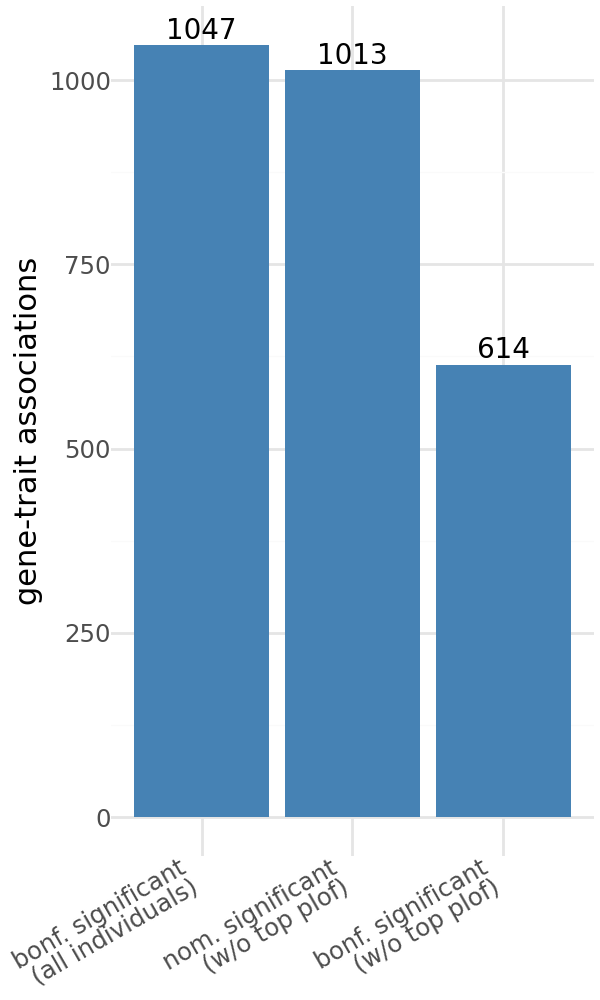

In [16]:
plt_df = pd.DataFrame({
    'categories': [
        'bonf. significant\n(all individuals)', 
        'nom. significant\n(w/o top plof)', 
        'bonf. significant\n(w/o top plof)', 
    ],
    'numbers': [
        gt_all.shape[0], 
        gt_all.filter(pl.col('pval_wo_top_plof')<0.05).shape[0],
        gt_all.filter(pl.col('pval_wo_top_plof')<0.05/17_500).shape[0],
    ]
})

category_order = plt_df['categories'].to_list()
plt_df['categories'] = pd.Categorical(
    plt_df['categories'].to_list(),
    categories=category_order,
    ordered=True
)


# --- 4. Create the Plot ---
(
    ggplot(plt_df, aes(x='categories', y='numbers'))
    + geom_col(fill='steelblue')
    + geom_text(
        aes(label='numbers'),
        va='bottom',
        nudge_y=0.001 * plt_df['numbers'].max(),
        size=10
    )
    + labs(
        x='',
        y='gene-trait associations',
    )
    + theme_minimal()
    + theme(
        figure_size=(3, 5),
        axis_text_x=element_text(rotation=30, hjust=1),
    )
)

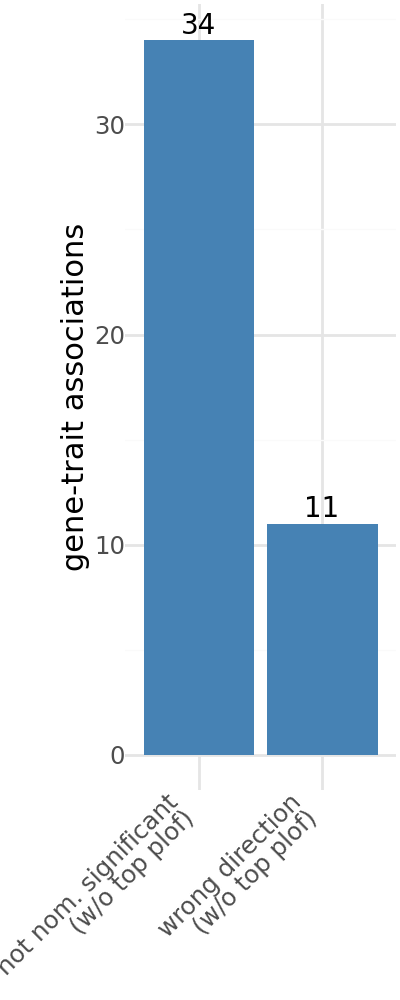

In [14]:
dir_df = pd.DataFrame({
    'categories': [ 
        'not nom. significant\n(w/o top plof)',
        'wrong direction\n(w/o top plof)',
    ],
    'numbers': [
        gt_all.filter(pl.col('pval_wo_top_plof')>0.05).shape[0],
        gt_all.filter(pl.col('beta')*pl.col('beta_wo_top_plof') < 0).shape[0],
    ]
})

category_order = dir_df['categories'].to_list()
dir_df['categories'] = pd.Categorical(
    dir_df['categories'].to_list(),
    categories=category_order,
    ordered=True
)


# --- 4. Create the Plot ---
(
    ggplot(dir_df, aes(x='categories', y='numbers'))
    + geom_col(fill='steelblue')
    + geom_text(
        aes(label='numbers'),
        va='bottom',
        nudge_y=0.001 * dir_df['numbers'].max(),
        size=10
    )
    + labs(
        x='',
        y='gene-trait associations',
    )
    + theme_minimal()
    + theme(
        figure_size=(2, 5),
        axis_text_x=element_text(rotation=45, hjust=1),
    )
)